In [2]:
import pandas as pd
df = pd.read_csv('DS_BreastCancer.csv')
# Display all column names
columns = df.columns.tolist()
print(columns)

['chembl_id', 'molregno', 'iupac_name', 'smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ro3_pass', 'num_ro5_violations', 'cx_logp', 'cx_logd', 'molecular_species', 'qed_weighted', 'np_likeness_score', 'ic50_value', 'ic50_units', 'standard_relation', 'target_name', 'target_type', 'cell_description', 'disease_name', 'disease_category', 'mechanism_of_action', 'action_type', 'warning_type', 'warning_description', 'IUPACName']


/var/folders/ky/j161912n7lvbtpf0r6nlk1xh0000gn/T/ipykernel_1522/721474221.py:2: DtypeWarning: Columns (0: warning_description) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('DS_BreastCancer.csv')


In [3]:
import numpy as np

In [4]:
#removed unnecessary columns
df1 = df[['smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ic50_value', 'ic50_units']]

In [5]:
# Remove all null values from df1
df1 = df1.dropna()
print(f"Shape after removing nulls: {df1.shape}")
print(df1.info())

Shape after removing nulls: (43617, 9)
<class 'pandas.DataFrame'>
Index: 43617 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            43617 non-null  str    
 1   molecular_weight  43617 non-null  float64
 2   aLogP             43617 non-null  float64
 3   hba               43617 non-null  float64
 4   hbd               43617 non-null  float64
 5   psa               43617 non-null  float64
 6   rtb               43617 non-null  float64
 7   ic50_value        43617 non-null  float64
 8   ic50_units        43617 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.3 MB
None


In [6]:
#checked whether the units of IC50 values are the sane
print(df1['ic50_units'].unique())

<StringArray>
['nM', 'ug.mL-1', 'ug', 'ug/g', '%', 'pmol/L', '10'5uM', '10'6uM', '10^3nM']
Length: 9, dtype: str


In [7]:
# Keep only rows with nM units
units_to_keep = ['nM']
df1 = df1[df1['ic50_units'].isin(units_to_keep)]
print(f"Shape after filtering: {df1.shape}")
print(df1['ic50_units'].value_counts())

Shape after filtering: (41691, 9)
ic50_units
nM    41691
Name: count, dtype: int64


In [8]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41691 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41691 non-null  str    
 1   molecular_weight  41691 non-null  float64
 2   aLogP             41691 non-null  float64
 3   hba               41691 non-null  float64
 4   hbd               41691 non-null  float64
 5   psa               41691 non-null  float64
 6   rtb               41691 non-null  float64
 7   ic50_value        41691 non-null  float64
 8   ic50_units        41691 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.2 MB


In [9]:
#added the pIC50 column
df1['pic50'] = -np.log10(df1['ic50_value']*1e-9)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Removed 1 rows with max pIC50 = 11.522878745280337
Shape after removing infinite values and max pIC50 outliers: (41686, 10)


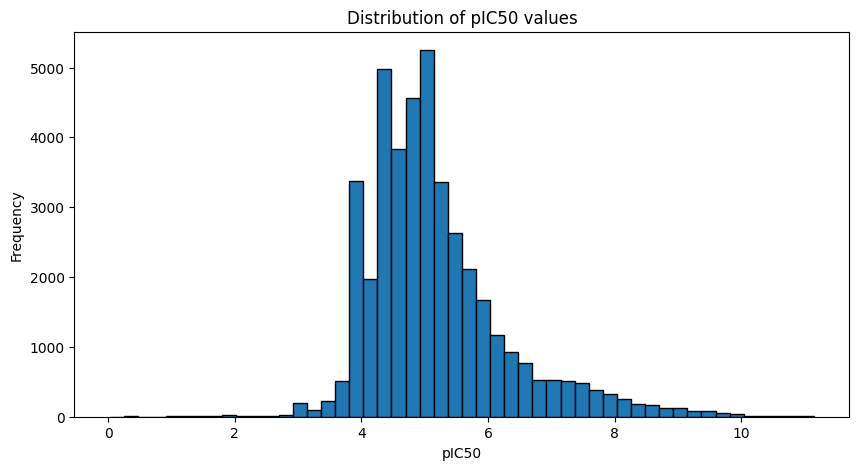

In [11]:
import matplotlib.pyplot as plt
# Remove infinite or NaN values
df1 = df1[np.isfinite(df1['pic50'])]

# Remove all rows with the maximum pIC50 value as outliers (I saw this at the box plot)
max_pic50 = df1['pic50'].max()
removed_count = df1[df1['pic50'] == max_pic50].shape[0]
df1 = df1[df1['pic50'] != max_pic50]
print(f"Removed {removed_count} rows with max pIC50 = {max_pic50}")
print(f"Shape after removing infinite values and max pIC50 outliers: {df1.shape}")

# Visualize the distribution of pIC50 values
plt.figure(figsize=(10, 5))
plt.hist(df1['pic50'], bins=50, edgecolor='black')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.title('Distribution of pIC50 values')
plt.show()


distribution is close to normal

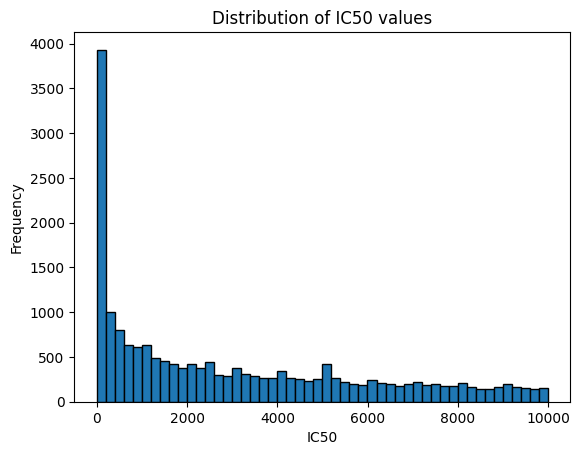

In [12]:
# Visualize the distribution of IC50 values (in nM)
plt.hist(df1['ic50_value'][df1['ic50_value']<10000], bins=50, edgecolor='black')
plt.xlabel('IC50')
plt.ylabel('Frequency')
plt.title('Distribution of IC50 values')
plt.show()

from these 2 graphs it is obvious that pIC50 distr is better for machine learning than IC50 values distr

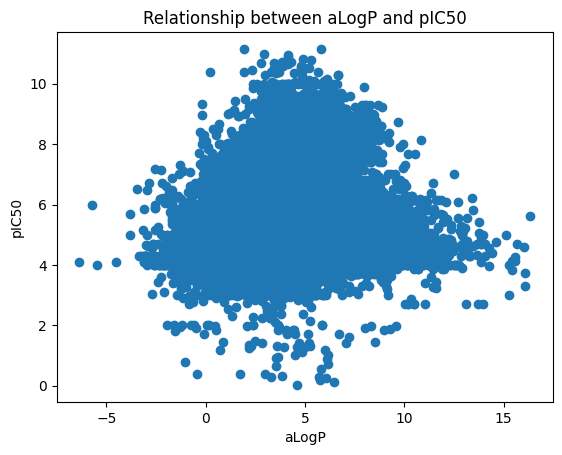

In [13]:
# Visualize the relationship between aLogP and pIC50
plt.scatter(df1['aLogP'], df1['pic50'])
plt.xlabel('aLogP')
plt.ylabel('pIC50')
plt.title('Relationship between aLogP and pIC50')
plt.show()

most active compounds (high pIC50) have approx 2<aLogP<7, which corresponds toLipinski's Rule of 5

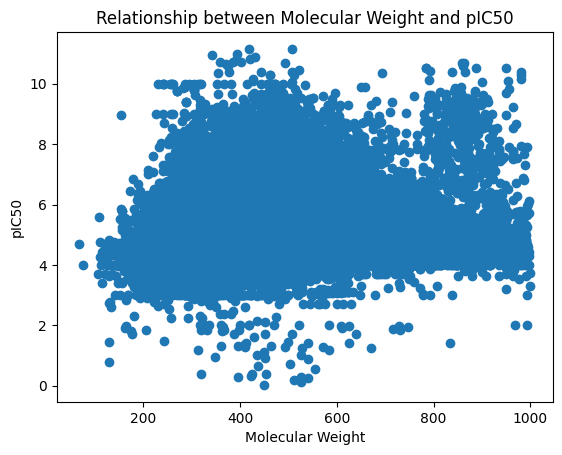

In [14]:
# Visualize the relationship between molecular weight and pIC50
plt.scatter(df1['molecular_weight'], df1['pic50'])
plt.xlabel('Molecular Weight')
plt.ylabel('pIC50')
plt.title('Relationship between Molecular Weight and pIC50')
plt.show()

most active compounds (high pIC50) have approx 200<molecular_weight<500 (small molecules don't have the required affinity to target proteins; large molecules get into cells with difficulty)

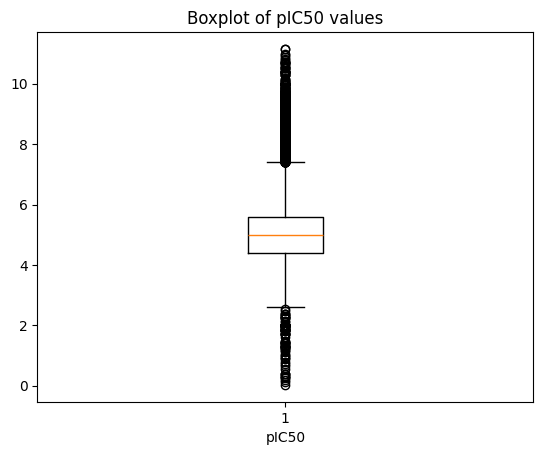

In [15]:
# Visualize the boxplot of pIC50 values
plt.boxplot(df1['pic50'])
plt.xlabel('pIC50')
plt.title('Boxplot of pIC50 values')
plt.show()

there was an obvious outlier at 13.8, I removed it earlier

In [16]:
df1['ic50_value'].describe()

count    4.168600e+04
mean     2.401649e+05
std      9.549084e+06
min      7.000000e-03
25%      2.500000e+03
50%      1.043500e+04
75%      4.000000e+04
max      9.506048e+08
Name: ic50_value, dtype: float64

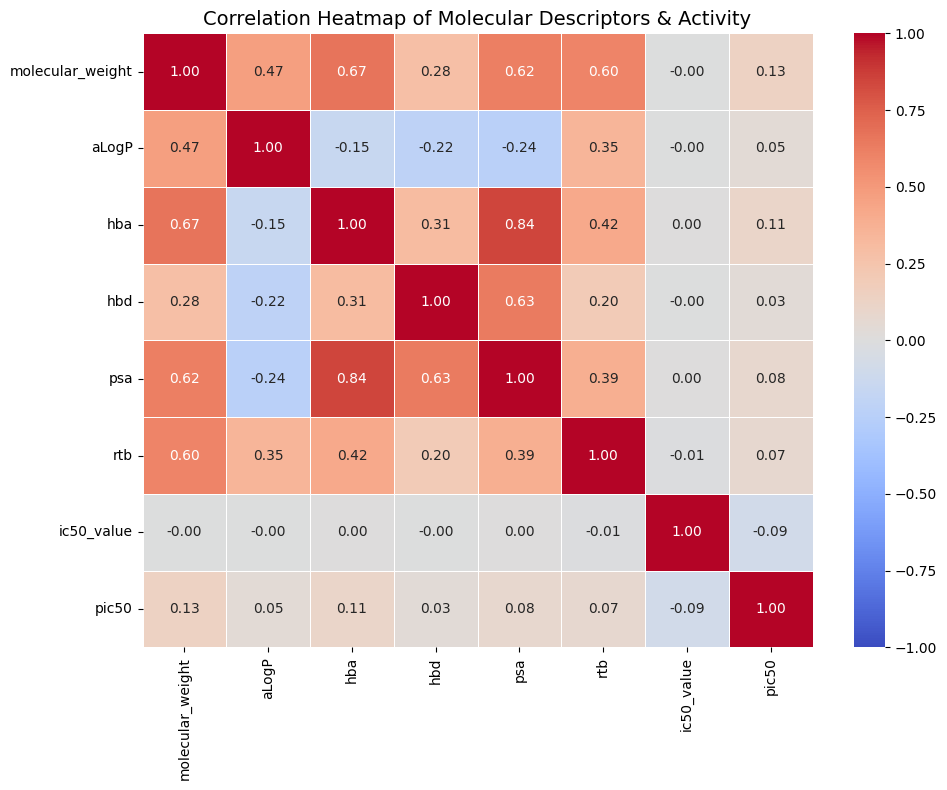

In [17]:
#creating a heatmap of correlations
import seaborn as sns

# 1. Отбираем только числовые колонки для анализа
# (ic50_value и pic50 сильно связаны, но pic50 линейнее, поэтому оставим все для проверки)
numeric_cols = [
    "molecular_weight",
    "aLogP",
    "hba",
    "hbd",
    "psa",
    "rtb",
    "ic50_value",
    "pic50",
]
corr_matrix = df1[numeric_cols].corr(method="pearson")

# 2. Настраиваем размер полотна
plt.figure(figsize=(10, 8))

# 3. Строим тепловую карту
sns.heatmap(
    corr_matrix,
    annot=True,  # Выводить коэффициенты внутри ячеек
    cmap="coolwarm",  # Красивая палитра: синий (минус) -> белый (ноль) -> красный (плюс)
    fmt=".2f",  # Округление до 2 знаков после запятой
    linewidths=0.5,  # Расстояние между ячейками
    vmin=-1,
    vmax=1,  # Границы шкалы
)

# 4. Добавляем заголовки
plt.title("Correlation Heatmap of Molecular Descriptors & Activity", fontsize=14)
plt.tight_layout()

# 5. Показываем график
plt.show()

strong correlation between molecular weight and polar surface area (PSA), since larger molecules tend to have larger surface areas. 

moderate correlation between aLogP andmolecular weight, since larger molecules often have more hydrophobic regions. 

strong correlation between hba and hbd, since both are related to the presence of hydrogen bond donors and acceptors in the molecule.

only -0.09 between pIC50 and ic50_value (cause pIC50 = -log10(IC50), non-linear relationship, see later)

In [18]:
#checking for pIC50 outliers that I mentioned earlier
a=df1[df1['pic50']==df1['pic50'].max()]
print(len(a))
print(a)

1
                                                  smiles  molecular_weight  \
17856  N#C/N=C(\NCCCCCCS(=O)(=O)N(OCCN1CCOCC1)C1CCC1)...            507.66   

       aLogP  hba  hbd     psa   rtb  ic50_value ic50_units      pic50  
17856   1.93  8.0  2.0  132.18  14.0       0.007         nM  11.154902  


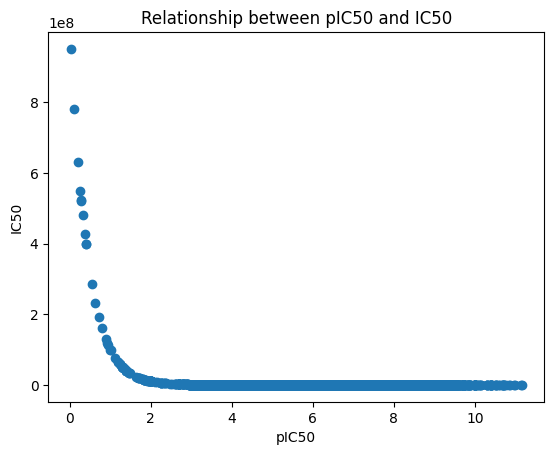

In [19]:
# Visualize the relationship between pIC50 and IC50 values
plt.scatter(df1['pic50'], df1['ic50_value'])
plt.xlabel('pIC50')
plt.ylabel('IC50')
plt.title('Relationship between pIC50 and IC50')
plt.show()

clear exponential relationship

99% of pIC50 values are in 0<IC50<1

but 1% spoils everything, so ic50_values cannot be used for machine learning at all

pIC50 should be used instead

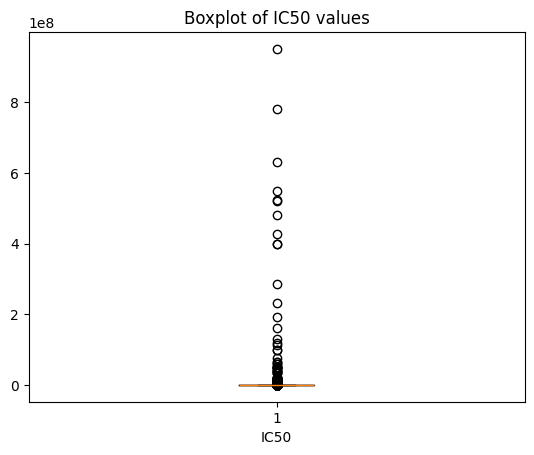

In [20]:
# Visualize the boxplot of IC50 values
plt.boxplot(df1['ic50_value'])
plt.xlabel('IC50')
plt.title('Boxplot of IC50 values')
plt.show()

insane number of outliers

ic50_values cannot be used for machine learning at all, pIC50 should be used instead

no need for ic50_values and ic50_units columns at this point

In [21]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41686 entries, 0 to 46290
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41686 non-null  str    
 1   molecular_weight  41686 non-null  float64
 2   aLogP             41686 non-null  float64
 3   hba               41686 non-null  float64
 4   hbd               41686 non-null  float64
 5   psa               41686 non-null  float64
 6   rtb               41686 non-null  float64
 7   ic50_value        41686 non-null  float64
 8   ic50_units        41686 non-null  str    
 9   pic50             41686 non-null  float64
dtypes: float64(8), str(2)
memory usage: 3.5 MB


In [22]:
df_final = df1.drop(columns=['ic50_value', 'ic50_units'])
print(df_final.info())

<class 'pandas.DataFrame'>
Index: 41686 entries, 0 to 46290
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41686 non-null  str    
 1   molecular_weight  41686 non-null  float64
 2   aLogP             41686 non-null  float64
 3   hba               41686 non-null  float64
 4   hbd               41686 non-null  float64
 5   psa               41686 non-null  float64
 6   rtb               41686 non-null  float64
 7   pic50             41686 non-null  float64
dtypes: float64(7), str(1)
memory usage: 2.9 MB
None


In [44]:
#preparing train data
df_x = df_final.drop(columns=['smiles', 'pic50'])
df_y = df_final['pic50']
print(df_x.info())
print(df_y.info())

<class 'pandas.DataFrame'>
Index: 41686 entries, 0 to 46290
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   molecular_weight  41686 non-null  float64
 1   aLogP             41686 non-null  float64
 2   hba               41686 non-null  float64
 3   hbd               41686 non-null  float64
 4   psa               41686 non-null  float64
 5   rtb               41686 non-null  float64
dtypes: float64(6)
memory usage: 2.2 MB
None
<class 'pandas.Series'>
Index: 41686 entries, 0 to 46290
Series name: pic50
Non-Null Count  Dtype  
--------------  -----  
41686 non-null  float64
dtypes: float64(1)
memory usage: 651.3 KB
None


# Linear Regression Model

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    df_x,
    df_y,
    test_size=0.2,
    random_state=42
)

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)

#predicted pic50 values for the test set
y_pred = lr.predict(X_test)

In [52]:
#coeffitions of linear regression model
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})
print(coeff_df.sort_values(by='Coefficient', ascending=False))

            Feature  Coefficient
2               hba     0.020726
3               hbd     0.010750
0  molecular_weight     0.001369
4               psa    -0.002032
5               rtb    -0.002768
1             aLogP    -0.021512


Accuracy evaluation

In [48]:
#Mean Squared Error between predicted and actual pic50 values
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

#Root Mean Squared Error
rmse = np.sqrt(mse)
print("RMSE:", rmse)

#R2
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

MSE: 1.240411045671025
RMSE: 1.1137374222279797
R2: 0.017080483350355058


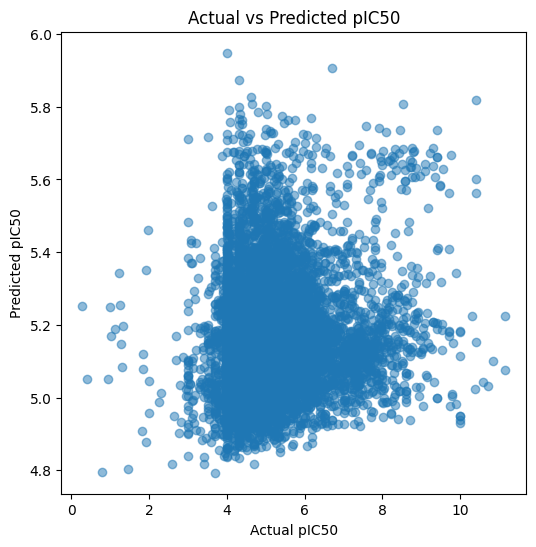

In [53]:
#pred VS exp plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50")
plt.show()

Conclusion: linear regression model is completely useless due to extremely low R2 value (0.017), so it doen't describe the relationship at all. This can be proved by a plot, that looks like a random cloud

R2 with scaling: 0.017080483350355058
RMSE with scaling: 1.1137374222279797


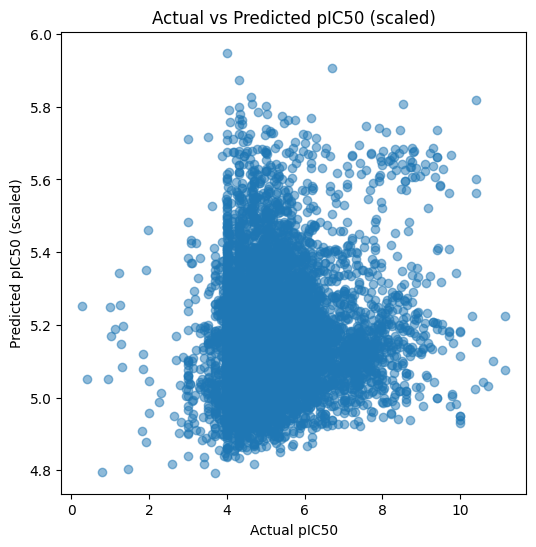

In [64]:
#trying linear regression scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr.fit(X_train_scaled, y_train)
y_pred_scaled = lr.predict(X_test_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)
print("R2 with scaling:", r2_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
print("RMSE with scaling:", rmse_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_scaled, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50 (scaled)")
plt.title("Actual vs Predicted pIC50 (scaled)")
plt.show()

Conclusion: linear regression with scaling model is completely useless as well

# Random Forest

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [61]:
r2_rf = r2_score(y_test, y_pred_rf)
print("R2 with Random Forest:", r2_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE with Random Forest:", rmse_rf)

R2 with Random Forest: 0.3943231655737972
RMSE with Random Forest: 0.8742674611084151


In [63]:
#coefficients of random forest model
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})
print(feature_importance_df.sort_values(by='Importance', ascending=False))

            Feature  Importance
4               psa    0.292727
0  molecular_weight    0.236678
1             aLogP    0.211427
5               rtb    0.093928
2               hba    0.090891
3               hbd    0.074349


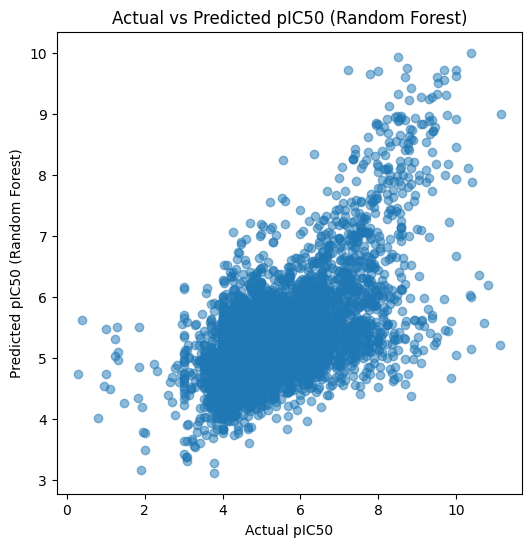

In [62]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50 (Random Forest)")
plt.title("Actual vs Predicted pIC50 (Random Forest)")
plt.show()

Conclusion:
R2 value for random forest regression is better than in case of the regular scikit learn model (0.394>0.017). This also can be seen from the plot: it is not as chaotic as the one based on the regular linear regression, at least the upward can be observed, but still there is a large cloud approx in the range between 3 and 8. The model demonstrates moderate predictive capability but is not sufficiently accurate for reliable endpoint prediction in real-world applications.